#### Train Set과 Test Set의 필요성
- 문제와 답을 알려주고 점수를 내면 항상 100점
- 하나의 Data Set을 Train / Test로 분리
- Train set으로 학습 -> 결과를 Test set에서 검증

In [3]:
import pandas as pd

In [2]:
fruits = pd.read_csv('../Data/fruits.csv')
fruits.head()

,length,weight,name
0,25.4,242.0,apple
1,26.3,290.0,apple
2,26.5,340.0,apple
3,29.0,363.0,apple
4,29.0,430.0,apple


#### Train / Test Set 분리

In [4]:

# Train Set
train_input = fruits.loc[:34, ['length', 'weight']]
train_input.tail()

,length,weight
30,38.5,920.0
31,38.5,955.0
32,39.5,925.0
33,41.0,975.0
34,41.0,950.0


In [5]:
train_target = fruits.loc[:34, 'name']
train_target.tail()

30    apple
31    apple
32    apple
33    apple
34    apple
Name: name, dtype: object

In [8]:

# Test Set
test_input = fruits.loc[35:, ['length', 'weight']]
test_input.head()

,length,weight
35,9.8,6.7
36,10.5,7.5
37,10.6,7.0
38,11.0,9.7
39,11.2,9.8


In [9]:
test_target = fruits.loc[35:, 'name']
test_target.head()

35    berry
36    berry
37    berry
38    berry
39    berry
Name: name, dtype: object

#### KNN 이용한 분류

In [10]:
from sklearn.neighbors import KNeighborsClassifier

In [11]:
kn = KNeighborsClassifier()

In [12]:
kn.fit(train_input, train_target)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [15]:
print(kn.score(train_input, train_target))
print(kn.score(test_input, test_target))

1.0
0.0


> 샘플링 편향이 발생했다.

----

#### Numpy 이용하여 샘플링 편향을 제거하기

In [16]:
import numpy as np

In [17]:
np.random.seed(42)      # random sample을 하나로 정의하여 다른 모델에서도 동일한 값으로 진행
index = np.arange(49)
np.random.shuffle(index)
print(index)

[13 45 47 44 17 27 26 25 31 19 12  4 34  8  3  6 40 41 46 15  9 16 24 33
 30  0 43 32  5 29 11 36  1 21  2 37 35 23 39 10 22 18 48 20  7 42 14 28
 38]


In [22]:
# train data 구성
train_input = fruits.loc[index[:35], ['length', 'weight']]
train_input.tail()

,length,weight
11,31.0,500.0
36,10.5,7.5
1,26.3,290.0
21,34.0,685.0
2,26.5,340.0


In [20]:
train_target = fruits.loc[index[:35], 'name']
train_target.tail()

11    apple
36    berry
1     apple
21    apple
2     apple
Name: name, dtype: object

In [21]:
# test data 구성
test_input = fruits.loc[index[35:], ['length', 'weight']]
test_input.head()

,length,weight
37,10.6,7.0
35,9.8,6.7
23,35.0,680.0
39,11.2,9.8
10,31.0,475.0


In [23]:
test_target = fruits.loc[index[35:], 'name']
test_target.head()

37    berry
35    berry
23    apple
39    berry
10    apple
Name: name, dtype: object

#### Data의 분포를 산포도로 확인

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: xlabel='length', ylabel='weight'>

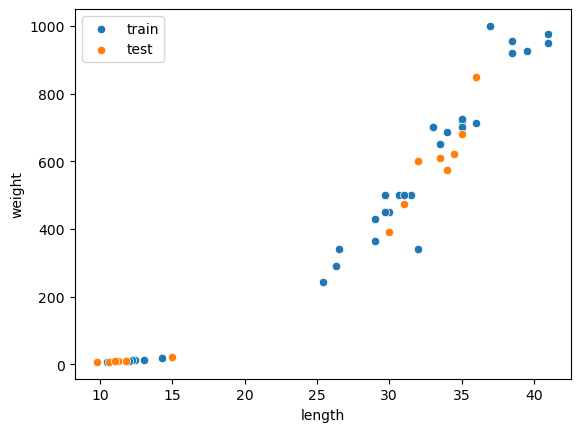

In [28]:
sns.scatterplot(
    data = train_input,
    x = 'length',
    y = 'weight',
    label = 'train'
)

sns.scatterplot(
    data = test_input,
    x = 'length',
    y = 'weight',
    label = 'test'
)

In [29]:
# knn 학습
kn.fit(train_input, train_target)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [31]:
kn.score(test_input, test_target)

1.0

----
#### sklearn 이용

In [32]:
from sklearn.model_selection import train_test_split

In [34]:
# feature / target 분리
fruits_data = fruits[['length', 'weight']]
fruits_target = fruits['name']
display(fruits_data.head(), fruits_target.head())

,length,weight
0,25.4,242.0
1,26.3,290.0
2,26.5,340.0
3,29.0,363.0
4,29.0,430.0


0    apple
1    apple
2    apple
3    apple
4    apple
Name: name, dtype: object

In [ ]:
train_input, test_input, train_target, test_target = \
    train_test_split(
        fruits_data,
        fruits_target,
        random_state = 42
    )

#### 빈도수 확인
: Sample(표본)은 모집단의 비율 유지

In [36]:
import collections

In [37]:
# fruits의 성격
collections.Counter(fruits['name'])

Counter({'apple': 35, 'berry': 14})

In [40]:
collections.Counter(train_target)

Counter({'apple': 25, 'berry': 11})

In [41]:
collections.Counter(test_target)

Counter({'apple': 10, 'berry': 3})

In [42]:
train_input, test_input, train_target, test_target = \
    train_test_split(
        fruits_data,
        fruits_target,
        random_state = 42,
        stratify = fruits_target        # fruits_target의 비율을 맞춤 / 층화추출(Stratified Sampling)
    )

In [44]:
print(collections.Counter(fruits_target))
print(collections.Counter(train_target))
print(collections.Counter(test_target))

Counter({'apple': 35, 'berry': 14})
Counter({'apple': 26, 'berry': 10})
Counter({'apple': 9, 'berry': 4})
